In [ ]:
from models import *

# Load Dataset
path = "../data/MNIST"
X_train, y_train, X_test, y_test = load_MINST_dataset(path)
X_train, X_test = flatten_images(X_train, X_test)

In [13]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.pipeline import Pipeline

def tune_linear_pipeline(X_train, y_train, X_test, y_test, c_options, dim_reduction):
    results = {}
    
    for c in c_options:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('reduce_dim', dim_reduction),
            ('svc', SVC(kernel='linear', C=c, random_state=42))
        ], verbose=True)
        print(f"Training Linear SVC with C={c}...")
        results[c] = evaluate_pipeline(pipeline, X_train, y_train, X_test, y_test)
        
    return results

def plot_pipeline_results(result, title):
    x = list(result.keys())
    train_time = [result[k]['train_time'] for k in x]
    train_acc = [result[k]['train_acc'] for k in x]
    test_acc = [result[k]['test_acc'] for k in x]

    plt.figure(figsize=(6.5, 4.5))

    # Accuracy
    plt.plot(x, train_acc, marker='o', label='Train Accuracy', color='blue')
    plt.plot(x, test_acc, marker='s', label='Test Accuracy', color='green')
    plt.xscale('log')
    plt.xlabel('Hyperparameter (C)')
    plt.ylabel('Accuracy')
    plt.title(f'Training and Test Accuracy ({title})')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    table = pd.DataFrame(result).T
    table = table[['train_time', 'train_acc', 'test_acc']].copy()
    table.columns = ['Training Time','Training Accuracy', 'Test Accuracy']

    return result, table

def tune_linear_svc(X_train, y_train, x_test, y_test, c_options, title, train_size = 5000):
    if train_size == 1:
        X_tune, y_tune = X_train, y_train
    else:
        X_tune, _, y_tune, _ = train_test_split(
            X_train, 
            y_train, 
            train_size=train_size, 
            stratify=y_train,
            random_state=42
        )
    result = {}

    for c in c_options:
        model = LinearSvc(c, max_iter = -1)
        result[c] = evaluate_model(model, X_tune, y_tune, x_test, y_test)

    x = list(result.keys())
    train_time = [result[k]['train_time'] for k in x]
    train_acc = [result[k]['train_acc'] for k in x]
    test_acc = [result[k]['test_acc'] for k in x]

    plt.figure(figsize=(6.5, 4.5))

    # Accuracy
    plt.plot(x, train_acc, marker='o', label='Train Accuracy', color='blue')
    plt.plot(x, test_acc, marker='s', label='Test Accuracy', color='green')
    plt.xscale('log')
    plt.xlabel('Hyperparameter (C)')
    plt.ylabel('Accuracy')
    plt.title(f'Training and Test Accuracy ({title})')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    table = pd.DataFrame(result).T
    table = table[['train_acc', 'test_acc']].copy()
    table.columns = ['Training Accuracy', 'Test Accuracy']

    return result, table

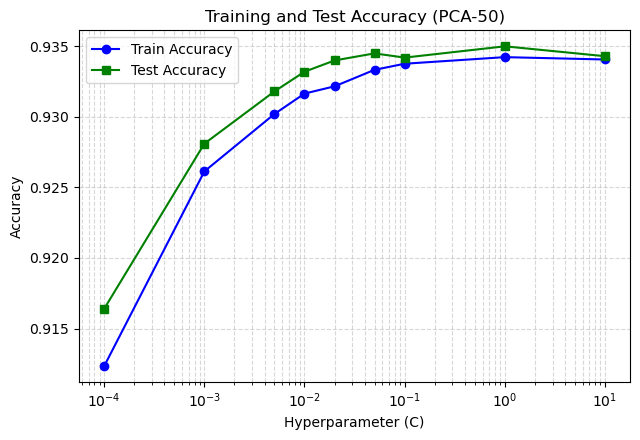

{0.0001: {'train_time': 29.76844553099363, 'train_acc': 0.9123333333333333, 'test_acc': 0.9164}, 0.001: {'train_time': 14.415382190003584, 'train_acc': 0.9261333333333334, 'test_acc': 0.9281}, 0.005: {'train_time': 14.051897889999964, 'train_acc': 0.9302, 'test_acc': 0.9318}, 0.01: {'train_time': 14.120614709005167, 'train_acc': 0.93165, 'test_acc': 0.9332}, 0.02: {'train_time': 14.237201702002494, 'train_acc': 0.9321666666666667, 'test_acc': 0.934}, 0.05: {'train_time': 17.481170690996805, 'train_acc': 0.9333333333333333, 'test_acc': 0.9345}, 0.1: {'train_time': 19.428435084999364, 'train_acc': 0.9337666666666666, 'test_acc': 0.9342}, 1: {'train_time': 81.22004202099924, 'train_acc': 0.9342333333333334, 'test_acc': 0.935}, 10: {'train_time': 588.9480558850046, 'train_acc': 0.9340666666666667, 'test_acc': 0.9343}}
         Training Time  Training Accuracy  Test Accuracy
0.0001       29.768446           0.912333         0.9164
0.0010       14.415382           0.926133         0.9281
0.0

In [ ]:
c_options = [0.0001, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 1, 10]
c_options_200 = [0.0001, 0.001, 0.002, 0.003, 0.005, 0.007, 0.01, 0.1, 1]

results_50 = tune_linear_pipeline(X_train, y_train, X_test, y_test, c_options, PCA(n_components=50))
results_50, table_50 = plot_pipeline_results(results_50, "PCA-50")
print(results_50)
print(table_50)

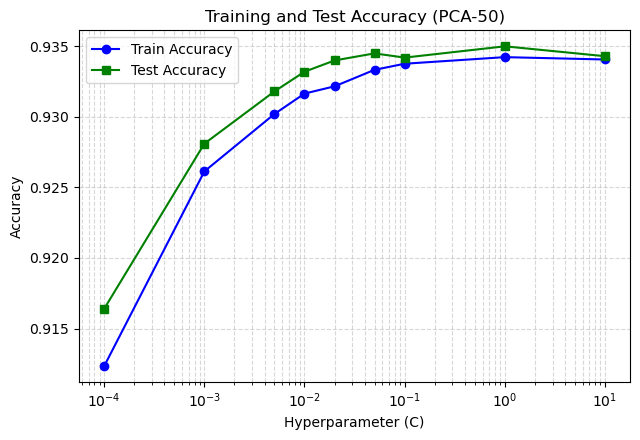

,Training Accuracy,Test Accuracy
0.0001,0.912333,0.9164
0.0010,0.926133,0.9281
0.0050,0.930200,0.9318
0.0100,0.931650,0.9332
0.0200,0.932167,0.9340
0.0500,0.933333,0.9345
0.1000,0.933767,0.9342
1.0000,0.934233,0.9350
10.0000,0.934067,0.9343


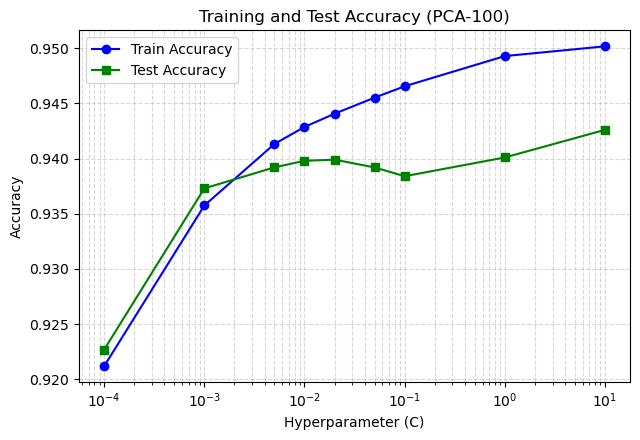

{0.0001: {'train_time': 43.068827410002996, 'train_acc': 0.9212, 'test_acc': 0.9227}, 0.001: {'train_time': 19.9354943119979, 'train_acc': 0.93575, 'test_acc': 0.9373}, 0.005: {'train_time': 15.271158995004953, 'train_acc': 0.9413166666666667, 'test_acc': 0.9392}, 0.01: {'train_time': 14.379992511996534, 'train_acc': 0.9428666666666666, 'test_acc': 0.9398}, 0.02: {'train_time': 15.674327654996887, 'train_acc': 0.9440666666666667, 'test_acc': 0.9399}, 0.05: {'train_time': 18.07803104100458, 'train_acc': 0.9455166666666667, 'test_acc': 0.9392}, 0.1: {'train_time': 23.42169287500292, 'train_acc': 0.94655, 'test_acc': 0.9384}, 1: {'train_time': 96.34203365700523, 'train_acc': 0.9492833333333334, 'test_acc': 0.9401}, 10: {'train_time': 824.6055447580002, 'train_acc': 0.9501666666666667, 'test_acc': 0.9426}}
         Training Time  Training Accuracy  Test Accuracy
0.0001       43.068827           0.921200         0.9227
0.0010       19.935494           0.935750         0.9373
0.0050       15

In [ ]:
results_100 = tune_linear_pipeline(X_train, y_train, X_test, y_test, c_options, PCA(n_components=100))
results_100, table_100 = plot_pipeline_results(results_100, "PCA-100")
print(results_100)
print(table_100)

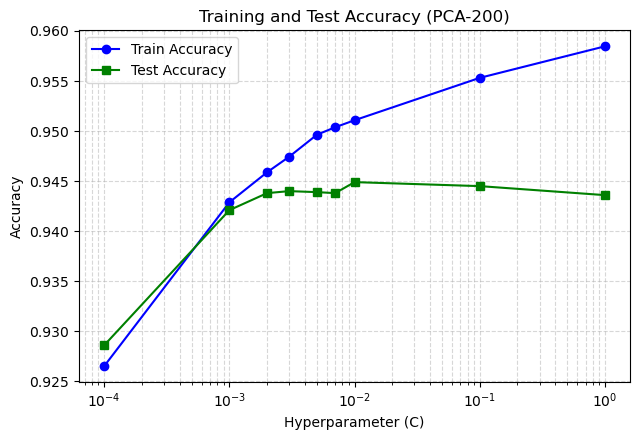

{0.0001: {'train_time': 105.8311264560034, 'train_acc': 0.9265166666666667, 'test_acc': 0.9286}, 0.001: {'train_time': 48.096166064999125, 'train_acc': 0.9428833333333333, 'test_acc': 0.9421}, 0.002: {'train_time': 38.549579954000365, 'train_acc': 0.9458833333333333, 'test_acc': 0.9438}, 0.003: {'train_time': 35.79809704399668, 'train_acc': 0.9474333333333333, 'test_acc': 0.944}, 0.005: {'train_time': 35.07878202899883, 'train_acc': 0.9496333333333333, 'test_acc': 0.9439}, 0.007: {'train_time': 31.530684017998283, 'train_acc': 0.9503833333333334, 'test_acc': 0.9438}, 0.01: {'train_time': 33.64367893799499, 'train_acc': 0.9510833333333333, 'test_acc': 0.9449}, 0.1: {'train_time': 51.41177792799863, 'train_acc': 0.9553166666666667, 'test_acc': 0.9445}, 1: {'train_time': 161.99292968000373, 'train_acc': 0.9584666666666667, 'test_acc': 0.9436}}
        Training Time  Training Accuracy  Test Accuracy
0.0001     105.831126           0.926517         0.9286
0.0010      48.096166           0.9

In [ ]:

results_200 = tune_linear_pipeline(X_train, y_train, X_test, y_test, c_options, PCA(n_components=200))
results_200, table_200 = plot_pipeline_results(results_200, "PCA-200")
print(results_200)
print(table_200)